In [72]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_utils import load_agn_data
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('style.mplstyle')

from scipy.stats import linregress

prefix = "test"
suffix = "test"

colors = {'u': 'tab:blue',
          'g': 'tab:green',
          'r': 'tab:orange',
          'i': 'tab:red',
          'z': 'tab:brown',
          'y': 'tab:gray'}

def plot_stone_vs_this_work(
    merged_df,
    sigma_keys,  # dict: {'x': str, 'y': str, 'xerr': str|tuple, 'yerr': str|tuple, 'xlabel': str, 'ylabel': str}
    tau_keys,    # dict: {'x': str, 'y': str, 'xerr': str|tuple, 'yerr': str|tuple, 'xlabel': str, 'ylabel': str}
    bands=('g', 'r', 'i'),
    figsize=(12, 7.6),
    band_colors=None,
    show=True,
    figfile='plots/appendix/stone.png'
):
    if band_colors is None:
        band_colors = {'g': 'tab:green', 'r': 'tab:red', 'i': 'tab:purple'}

    ncols = len(bands)
    fig, axes = plt.subplots(2, ncols, figsize=figsize, constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0.01, wspace=0.0, hspace=0.02)

    axes = np.atleast_2d(axes)

    def _limits(x, y, pad=0.04):
        lo = np.nanmin([np.nanmin(x), np.nanmin(y)])
        hi = np.nanmax([np.nanmax(x), np.nanmax(y)])
        rng = max(hi - lo, 1e-6)
        return lo - pad * rng, hi + pad * rng

    def _style(ax):
        ax.tick_params(direction='in', which='both', top=True, right=True, length=3, pad=2)
        for s in ax.spines.values():
            s.set_linewidth(1.1)
        ax.legend(loc='upper left', frameon=True, fancybox=True, framealpha=1,
                  edgecolor='0.2', facecolor='white', fontsize=11)

    def _maybe_get(df, pattern, band):
        if pattern is None:
            return None
        if isinstance(pattern, tuple):
            lo = df[pattern[0].format(band=band)].to_numpy()
            up = df[pattern[1].format(band=band)].to_numpy()
            return (lo, up)
        return df[pattern.format(band=band)].to_numpy()

    def _extract_xyerr(df, keydict, band):
        x = df[keydict['x'].format(band=band)].to_numpy()
        y = df[keydict['y'].format(band=band)].to_numpy()
        xerr = _maybe_get(df, keydict.get('xerr'), band)
        yerr = _maybe_get(df, keydict.get('yerr'), band)

        m = np.isfinite(x) & np.isfinite(y)
        if isinstance(xerr, tuple):
            m &= np.isfinite(xerr[0]) & np.isfinite(xerr[1])
        elif xerr is not None:
            m &= np.isfinite(xerr)
        if isinstance(yerr, tuple):
            m &= np.isfinite(yerr[0]) & np.isfinite(yerr[1])
        elif yerr is not None:
            m &= np.isfinite(yerr)

        if m.sum() == 0:
            return None

        x, y = x[m], y[m]
        if isinstance(xerr, tuple):
            xerr = (xerr[0][m], xerr[1][m])
        elif xerr is not None:
            xerr = xerr[m]
        if isinstance(yerr, tuple):
            yerr = (yerr[0][m], yerr[1][m])
        elif yerr is not None:
            yerr = yerr[m]
        return x, y, xerr, yerr

    # ---------- Top row: σ ----------
    for ax, band in zip(axes[0], bands):
        data = _extract_xyerr(merged_df, sigma_keys, band)
        if data is None:
            ax.set_visible(False)
            continue
        x, y, xerr, yerr = data

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                    color='0.35', alpha=0.28, lw=1.4, capsize=3, capthick=1, zorder=-9)
        ax.scatter(x, y, s=18, alpha=0.9, edgecolor='k', facecolor='k', linewidths=0.5, zorder=-8)

        xmin, xmax = _limits(x, y)
        line_color = band_colors.get(band, '0.2')
        ax.plot([xmin, xmax], [xmin, xmax], ls='--', lw=2.0, color=line_color,
                label=rf'$y=x$ ({band})', zorder=-4)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(sigma_keys.get('xlabel').format(band=band), labelpad=1)
        ax.set_ylabel(sigma_keys.get('ylabel').format(band=band), labelpad=1)
        _style(ax)

    # ---------- Bottom row: τ ----------
    for ax, band in zip(axes[1], bands):
        data = _extract_xyerr(merged_df, tau_keys, band)
        if data is None:
            ax.set_visible(False)
            continue
        x, y, xerr, yerr = data

        ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='none',
                    color='0.35', alpha=0.28, lw=1.4, capsize=3, capthick=1, zorder=-9)
        ax.scatter(x, y, s=18, alpha=0.9, edgecolor='k', facecolor='k', linewidths=0.5, zorder=-8)

        xmin, xmax = _limits(x, y)
        line_color = band_colors.get(band, '0.2')
        ax.plot([xmin, xmax], [xmin, xmax], ls='--', lw=2.0, color=line_color,
                label=rf'$y=x$ ({band})', zorder=-4)
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_aspect('equal', adjustable='box')

        ax.set_xlabel(tau_keys.get('xlabel').format(band=band), labelpad=1)
        ax.set_ylabel(tau_keys.get('ylabel').format(band=band), labelpad=1)
        _style(ax)

    for j in range(ncols):
        axes[0, j].tick_params(labelbottom=False)
    for i in range(2):
        for j in range(1, ncols):
            axes[i, j].tick_params(labelleft=False)

    fig.savefig(figfile, dpi=600)


    if show:
        plt.show()
    plt.close(fig)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
stone_df = pd.read_csv('data/sept3_stone_lcs.csv')
stone_df['object_id']

0      1389354.0
1      1388636.0
2      1387156.0
3      1389729.0
4      1389887.0
         ...    
185    1390847.0
186    1390837.0
187    1389212.0
188    1388108.0
189    1388322.0
Name: object_id, Length: 190, dtype: float64

In [32]:
agn_df = load_agn_data("results/data/sep17arb_sep8_stonelcs_fake_N20w4000s1000t8co4ch4.h5", populate_sdss=False, apply_cut=False, only_load=True)
agn_df['object_id'] = agn_df['object_id'].astype(str)

Reading quasars from HDF5:   0%|          | 0/189 [00:00<?, ?it/s]

Reading quasars from HDF5: 100%|██████████| 189/189 [00:02<00:00, 74.08it/s]


Number of quasars loaded: 189


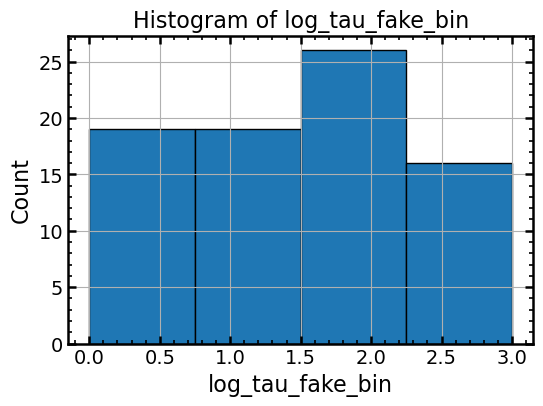

In [36]:
# Divide agn_df with log_tau_fake < 3 into four bins by log_tau_fake
bins = np.linspace(agn_df.loc[agn_df['log_tau_fake'] < 3, 'log_tau_fake'].min(),
                   agn_df.loc[agn_df['log_tau_fake'] < 3, 'log_tau_fake'].max(), 5)
agn_df['log_tau_fake_bin'] = pd.cut(agn_df['log_tau_fake'], bins=bins, labels=False, include_lowest=True)

plt.figure(figsize=(6, 4))
agn_df['log_tau_fake_bin'].hist(bins=4, edgecolor='k')
plt.xlabel('log_tau_fake_bin')
plt.ylabel('Count')
plt.title('Histogram of log_tau_fake_bin')
plt.show()

Saved injected vs recovery sigma and tau plot to plots/multiband/test/sigmatau/test.png


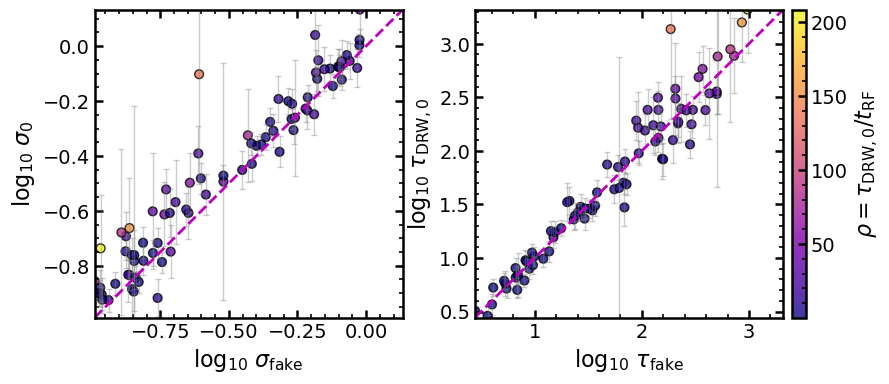

Bin 0: object_id = 1386837, log_tau_fake = 0.842, log_tau_drw0 = 0.842
log_tau_fake      0.841554
log_tau_drw0      0.841983
log_sigma_fake   -0.938491
log_sigma0       -0.925358
Name: 5, dtype: object
Bin 1: object_id = 1387819, log_tau_fake = 1.364, log_tau_drw0 = 1.360
log_tau_fake       1.36383
log_tau_drw0      1.360363
log_sigma_fake   -0.349613
log_sigma0       -0.275884
Name: 50, dtype: object
Bin 2: object_id = 1387636, log_tau_fake = 1.971, log_tau_drw0 = 1.977
log_tau_fake      1.971092
log_tau_drw0      1.977492
log_sigma_fake    -0.33773
log_sigma0       -0.308397
Name: 40, dtype: object
Bin 3: object_id = 1389488, log_tau_fake = 2.368, log_tau_drw0 = 2.392
log_tau_fake      2.368286
log_tau_drw0      2.391996
log_sigma_fake    -0.69444
log_sigma0       -0.568257
Name: 119, dtype: object


In [74]:
d = agn_df[agn_df['log_tau_fake'] < 3]


# Panel 1: log_sigma_fake vs log_sigma0
log_sigma_fake = d['log_sigma_fake'].to_numpy()
log_sigma0 = d['log_sigma0'].to_numpy()
log_sigma0_err = d['log_sigma0_err'].to_numpy()
log_tau_fake = d['log_tau_fake'].to_numpy()
log_tau_drw0 = d['log_tau_drw0'].to_numpy()
log_tau_drw0_err = d['log_tau_drw0_err'].to_numpy()

t_obs_length = 10
t_rf_length = 10
rho = 10**log_tau_drw0 / t_rf_length if t_rf_length > 0 else np.nan

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Panel 1: log_sigma_fake vs log_sigma0, color by rho
x1 = log_sigma_fake
y1 = log_sigma0
y1err = log_sigma0_err
c1 = rho
xmin1, xmax1 = min(x1.min(), y1.min()), max(x1.max(), y1.max())
sc1 = axes[0].scatter(x1, y1, c=c1, cmap='plasma', s=40, edgecolor='k', alpha=0.8)
axes[0].errorbar(x1, y1, yerr=y1err, fmt='none', ecolor='gray', alpha=0.4, elinewidth=1, capsize=2)
axes[0].plot([xmin1, xmax1], [xmin1, xmax1], 'm--', lw=2)
axes[0].set_xlabel(r'$\log_{10}\,\sigma_\mathrm{fake}$')
axes[0].set_ylabel(r'$\log_{10}\,\sigma_0$')
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlim(xmin1, xmax1)
axes[0].set_ylim(xmin1, xmax1)

# Panel 2: log_tau_fake vs log_tau_drw0 (swapped x and y), color by rho
x2 = log_tau_fake
y2 = log_tau_drw0
y2err = log_tau_drw0_err
c2 = rho
xmin2, xmax2 = min(x2.min(), y2.min()), max(x2.max(), y2.max())
sc2 = axes[1].scatter(x2, y2, c=c2, cmap='plasma', s=40, edgecolor='k', alpha=0.8)
axes[1].errorbar(x2, y2, yerr=y2err, fmt='none', ecolor='gray', alpha=0.4, elinewidth=1, capsize=2)
axes[1].plot([xmin2, xmax2], [xmin2, xmax2], 'm--', lw=2)
axes[1].set_xlabel(r'$\log_{10}\,\tau_\mathrm{fake}$')
axes[1].set_ylabel(r'$\log_{10}\,\tau_\mathrm{DRW,0}$')
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_xlim(xmin2, xmax2)
axes[1].set_ylim(xmin2, xmax2)


# Add colorbar for the second panel (rho)
cax = fig.add_axes([axes[1].get_position().x1 + 0.01, axes[1].get_position().y0, 0.015, axes[1].get_position().height])
cbar2 = plt.colorbar(sc2, cax=cax)
cbar2.set_label(r'$\rho = \tau_\mathrm{DRW,0} / t_\mathrm{RF}$')

# Save
out_dir = f"plots/multiband/{prefix}/sigmatau/"
os.makedirs(out_dir, exist_ok=True)
save_path = os.path.join(out_dir, f"{suffix}.png")
fig.savefig(save_path, dpi=300)
print(f"Saved injected vs recovery sigma and tau plot to {save_path}")
plt.show()
plt.close(fig)

# Assign bin labels to each row in d based on log_tau_fake
d = d.copy()
d['tau_bin'] = pd.cut(d['log_tau_fake'], bins=bins, labels=False, include_lowest=True)

# For each bin, find the object closest to the y=x line
for i in range(4):
    bin_df = d[d['tau_bin'] == i]
    if bin_df.empty:
        print(f"Bin {i}: No objects")
        continue
    diff = np.abs(bin_df['log_tau_fake'] - bin_df['log_tau_drw0'])
    idx_min = diff.idxmin()
    obj_id = bin_df.loc[idx_min, 'object_id']
    print(f"Bin {i}: object_id = {obj_id}, log_tau_fake = {bin_df.loc[idx_min, 'log_tau_fake']:.3f}, log_tau_drw0 = {bin_df.loc[idx_min, 'log_tau_drw0']:.3f}")
    print(bin_df.loc[idx_min, ['log_tau_fake', 'log_tau_drw0', 'log_sigma_fake', 'log_sigma0']])

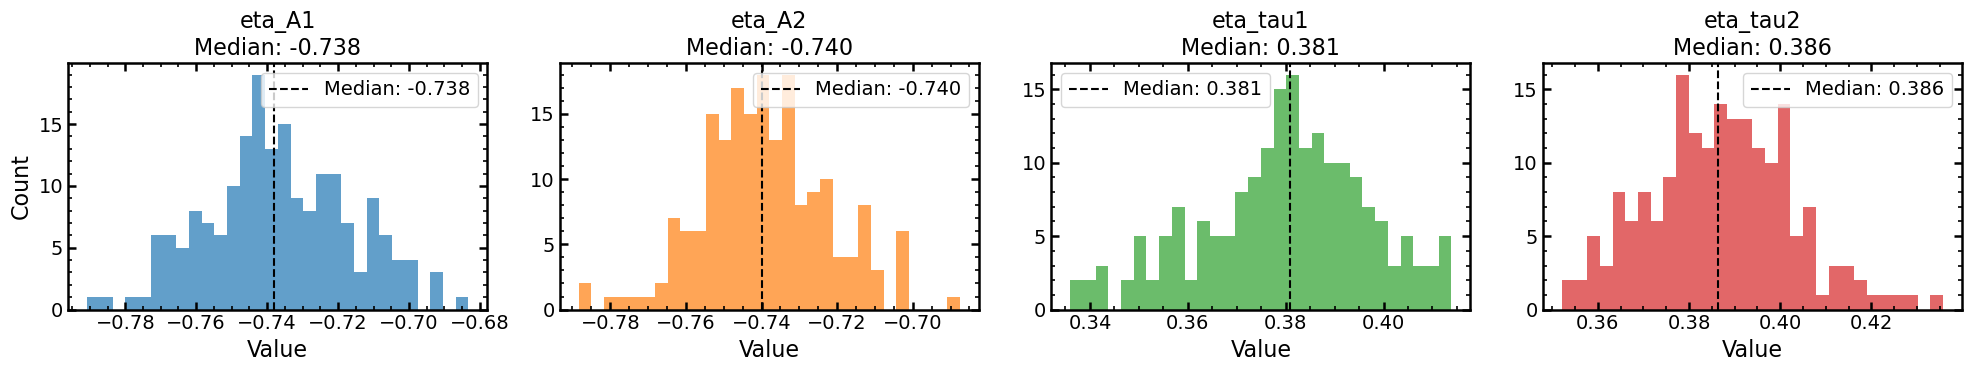

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=False, sharey=False)

cols = ['eta_A1', 'eta_A2', 'eta_tau1', 'eta_tau2']
#cols = ['eta_A1_mean', 'eta_A2_mean', 'eta_tau1_mean', 'eta_tau2_mean']

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
d = agn_df
mask = np.ones(len(d), dtype=bool)
# rhat_lim = 1.1
# mask &= ((d['eta_tau2_rhat'] < rhat_lim) & (d['eta_tau1_rhat'] < rhat_lim) 
#     & (d['eta_A1_rhat'] < rhat_lim) & (d['eta_A2_rhat'] < rhat_lim)
#     )
# mask &= (d['eta_tau2'] > 0) & (d['eta_tau1'] > 0)

# for i, (col, color) in enumerate(zip(cols, colors)):
#     data = d.loc[mask, col].dropna()
#     median = data.median()
#     axes[i].hist(data, bins=30, color=color, alpha=0.7)
#     axes[i].axvline(median, color='k', linestyle='--', label=f'Median: {median:.3f}')
#     axes[i].set_title(f'{col}\nMedian: {median:.3f}')
#     axes[i].set_xlabel('Value')
#     if i == 0:
#         axes[i].set_ylabel('Count')
#     axes[i].legend()

mean = {'eta_A1': -0.746, 'eta_A2': -0.746, 'eta_tau1': 0.5, 'eta_tau2': 0.5}
std = {'eta_A1': 0.3, 'eta_A2': 0.3, 'eta_tau1': 0.2, 'eta_tau2': 0.2}

for i, (col, color) in enumerate(zip(cols, colors)):
    data = d.loc[mask, col].dropna()
    median = data.median()

    # Histogram (counts, not density)
    n, bins, _ = axes[i].hist(data, bins=30, color=color, alpha=0.7)
    axes[i].axvline(median, color='k', linestyle='--', label=f'Median: {median:.3f}')

    # Resolve mu/sigma (support scalar or per-column dict)
    mu = mean[col] if isinstance(mean, dict) else float(mean)
    sigma = std[col] if isinstance(std, dict) else float(std)

    # Gaussian scaled to counts
    x = np.linspace(bins[0], bins[-1], 400)
    bin_w = bins[1] - bins[0]
    pdf = (1.0 / (sigma * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    y = pdf * len(data) * bin_w

    # Plot + semi-transparent fill
    axes[i].plot(x, y, color='k', lw=2, alpha=0.9, label=f'Gaussian μ={mu:.3f}, σ={sigma:.3f}', zorder=3)
    axes[i].fill_between(x, 0, y, color='k', alpha=0.25, zorder=2)

    axes[i].set_title(f'{col}\nMedian: {median:.3f}')
    axes[i].set_xlabel('Value')
    if i == 0:
        axes[i].set_ylabel('Count')
    axes[i].legend()


plt.tight_layout()
plt.show()


Reading quasars from HDF5: 100%|██████████| 189/189 [00:02<00:00, 78.20it/s]


Number of quasars loaded: 189


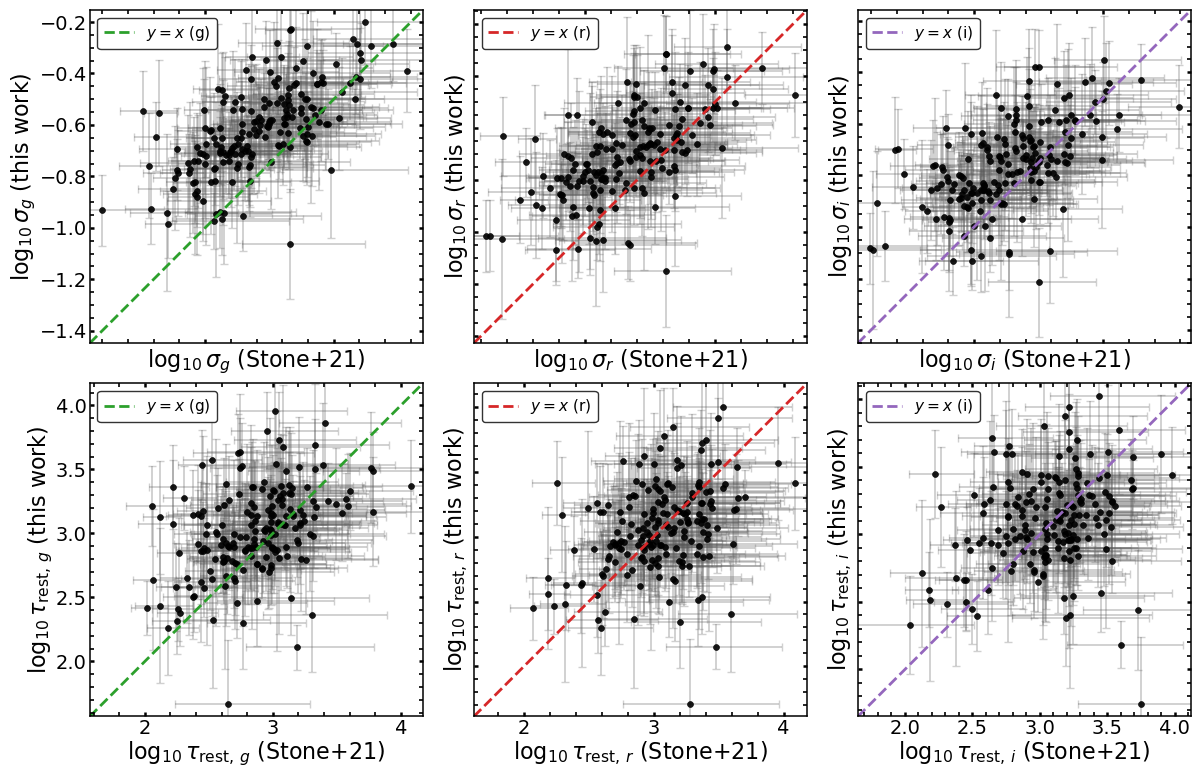

In [75]:
# Stone vs Stone LCs fitted no lag blr
sigma_keys = {
    'x': 'stone_log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('stone_log_SIGMA_{band}_ERR_L', 'stone_log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'stone_log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('stone_log_TAU_REST_{band}_ERR_L', 'stone_log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}


# Load stone data
stone_df = pd.read_csv('data/sept3_stone_lcs.csv', dtype={'object_id': str})
stone_df = stone_df.dropna(axis=0, subset=stone_df.select_dtypes(include=[np.number]).columns)

# Load standard data
agn_df = load_agn_data("results/data/sep18arc_sep8_stonelcs_csv_yupriors_N20w4000s500t8co4ch4.h5", populate_sdss=False, apply_cut=False, only_load=True)
agn_df['object_id'] = agn_df['object_id'].astype(str)
#agn_df = agn_df.dropna(axis=0, subset=agn_df.select_dtypes(include=[np.number]).columns)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))
plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_vs_stonelc_wopoly1_nolagblr_test.pdf")

Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 316.43it/s]


Number of quasars loaded: 180


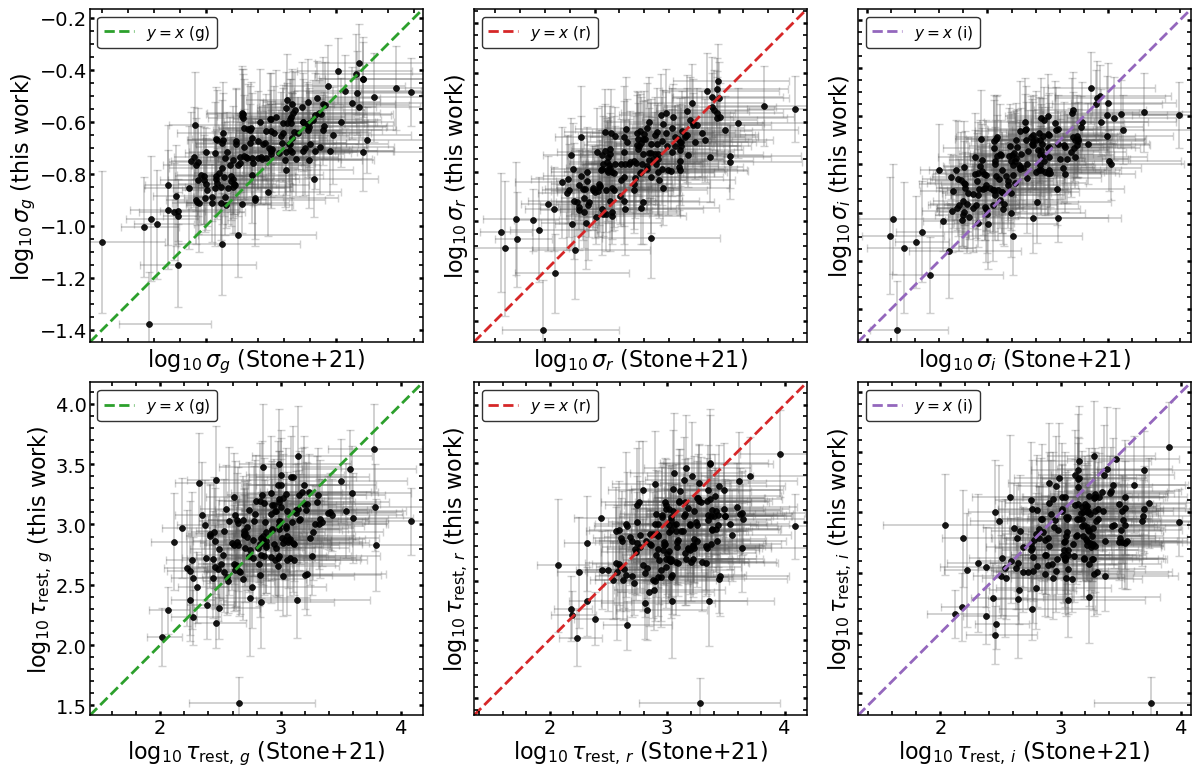

In [6]:
# Stone Comparison wo/ poly1

sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

# Load stone data
stone_df = pd.read_csv('data/aug8_stone_merged.csv')
stone_df['object_id'] = stone_df['object_id'].astype(str)

# Load standard data
agn_df = load_agn_data("results/data/aug19_stone_nobwb_nopoly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False, only_load=True)
agn_df['object_id'] = agn_df['object_id'].astype(str)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))


plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_wopoly1.pdf")


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 268.09it/s]


Number of quasars loaded: 180


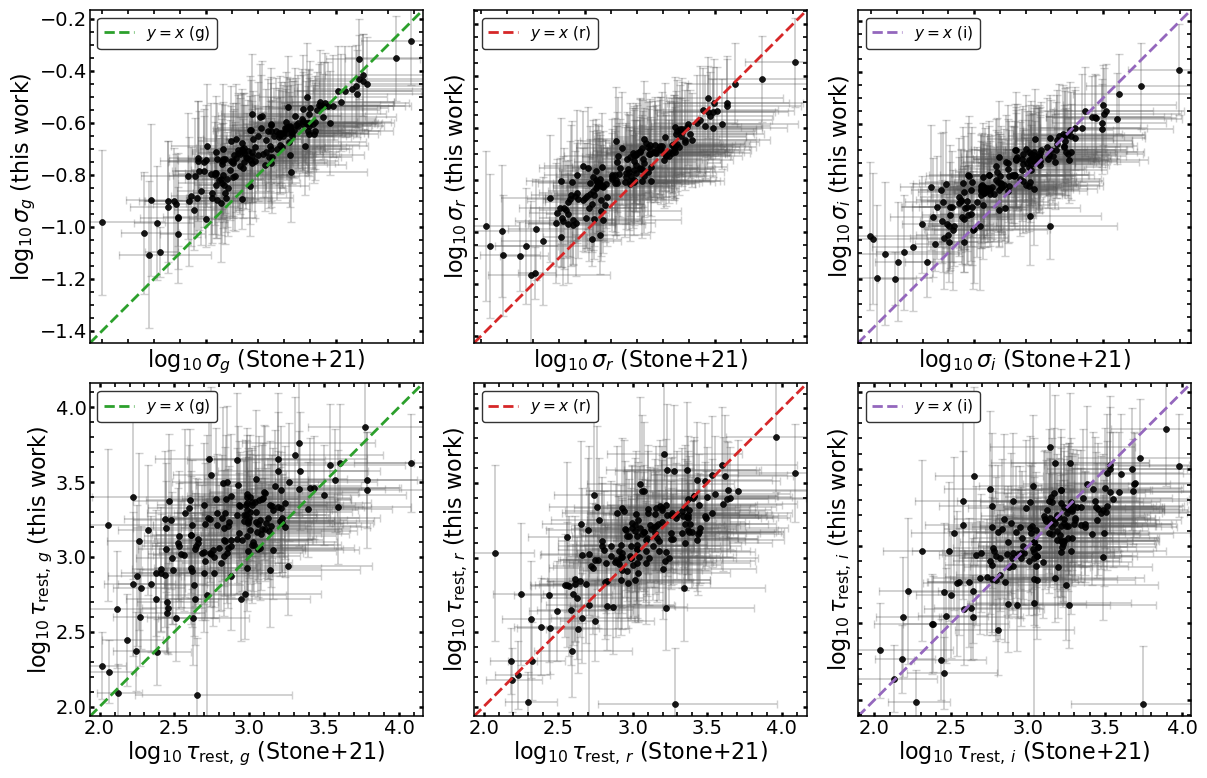

In [11]:
# Stone vs Stone LCs fitted no lag blr
sigma_keys = {
    'x': 'stone_log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('stone_log_SIGMA_{band}_ERR_L', 'stone_log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'stone_log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('stone_log_TAU_REST_{band}_ERR_L', 'stone_log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}


# Load stone data
stone_df = pd.read_csv('data/sept3_stone_lcs.csv', dtype={'object_id': str})
stone_df = stone_df.dropna(axis=0, subset=stone_df.select_dtypes(include=[np.number]).columns)

# Load standard data
agn_df = load_agn_data("results/data/sep3_chisq_stonelc_nobwb_nopoly1_nolagblr_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False, only_load=True)
agn_df['object_id'] = agn_df['object_id'].astype(str)
agn_df = agn_df.dropna(axis=0, subset=agn_df.select_dtypes(include=[np.number]).columns)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))
plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_vs_stonelc_wopoly1_nolagblr.pdf")

# Print object_id of objects close to the y=x line for g, r, i bands
bands = ['g', 'r', 'i']
tol = 0.05  # tolerance in log space

In [15]:
band = 'r'
x = merged_agn_stone[f'stone_log_TAU_REST_{band}']
y = merged_agn_stone[f'log_tau_band_{band}_RF']
close = np.abs(x - y) < tol
print(f"Band {band}:")
merged_agn_stone.loc[close, ['object_id', 'stone_log_TAU_REST_r', 'log_tau_band_r_RF']].head(32)

print(merged_agn_stone.loc[close, 'object_id'].head(32).to_list())

Band r:
['1389354', '1388636', '1387156', '1390435', '1390004', '1387687', '1387472', '1389486', '1389477', '1389026', '1388234', '1389767', '1388067', '1387164', '1387743', '1391150', '1387579', '1389488', '1389884', '1388577', '1387551', '1388817', '1387544', '1391199', '1390491', '1386655', '1387151', '1389198', '1388304', '1388819', '1388389', '1389088']


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 244.56it/s]


Number of quasars loaded: 180
[WARNING] alpha_lambda not in df, populating from CSV
Length of colin_df: 4000
Number with apparent_mag_2500 > 0: 3966
Length of merged DataFrame: 180
object_id not in merged: ['1388108', '1390331', '1387544', '1391217', '1390021', '1388070', '1388467', '1387618', '1390597', '1387321', '1389786', '1390026', '1387226', '1387164', '1387743', '1388389', '1389038', '1387528', '1389887', '1388577', '1389560', '1390319', '1390576', '1390992', '1388483', '1387174', '1387205', '1386720', '1387518', '1388573', '1391675', '1387938', '1390151', '1388366', '1389799', '1389026', '1388943', '1387264', '1388067', '1387099', '1389486', '1386875', '1391583', '1387876', '1388730', '1386822', '1388442', '1387472', '1389289', '1390559', '1390847', '1389832', '1390243', '1387714', '1387687', '1387044', '1389767', '1387579', '1388513', '1388643', '1387119', '1388819', '1387641', '1390490', '1389630', '1390080', '1387685', '1390677', '1387725', '1390858', '1388340', '1388047', '

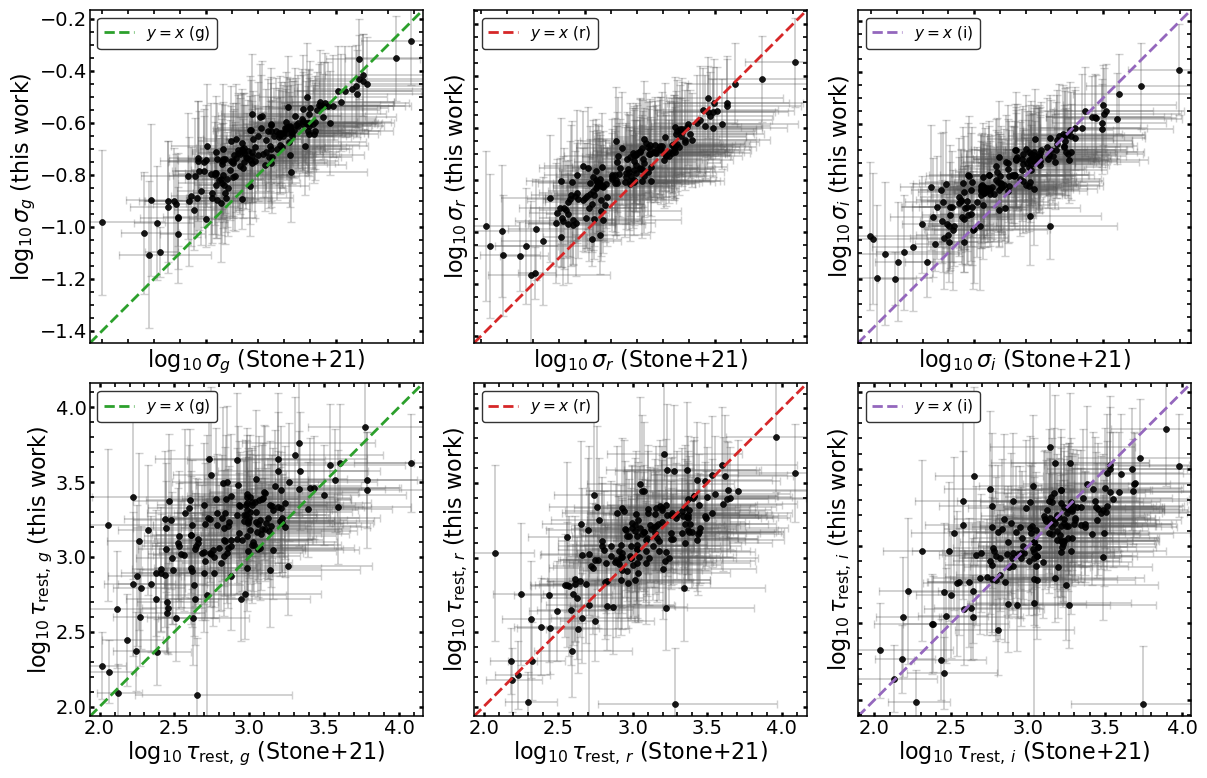

In [31]:
# Stone vs Stone LCs fitted
sigma_keys = {
    'x': 'stone_log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('stone_log_SIGMA_{band}_ERR_L', 'stone_log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'stone_log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('stone_log_TAU_REST_{band}_ERR_L', 'stone_log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}


# Load stone data
stone_df = pd.read_csv('data/sept3_stone_lcs.csv', dtype={'object_id': str})
stone_df = stone_df.dropna(axis=0, subset=stone_df.select_dtypes(include=[np.number]).columns)

# Load standard data
agn_df = load_agn_data("results/data/sep2_chisq_stonelc_nobwb_nopoly1_N20w4000s1000t8c4_spectralfit.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)
agn_df = agn_df.dropna(axis=0, subset=agn_df.select_dtypes(include=[np.number]).columns)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))
plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_vs_stonelc_wopoly1.pdf")


<unknown>:1027: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1034: SyntaxWarning: invalid escape sequence '\p'
Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 309.89it/s]


Number of quasars loaded: 180
[WARNING] alpha_lambda not in df, populating from CSV
Length of colin_df: 4000
Number with apparent_mag_2500 > 0: 3966
Length of merged DataFrame: 180
object_id not in merged: ['1388108', '1390331', '1387544', '1391217', '1390021', '1388070', '1388467', '1387618', '1390597', '1387321', '1389786', '1390026', '1387226', '1387164', '1390830', '1387743', '1388389', '1389038', '1387528', '1389887', '1388577', '1389560', '1390319', '1390576', '1390992', '1388483', '1387174', '1387205', '1386720', '1387518', '1388573', '1391675', '1387938', '1390151', '1388366', '1389799', '1389026', '1388166', '1387264', '1388067', '1387099', '1389486', '1386875', '1391583', '1387876', '1388730', '1386822', '1388442', '1387472', '1387498', '1389289', '1390559', '1390847', '1389832', '1390243', '1387714', '1387687', '1389767', '1387579', '1388270', '1388643', '1387119', '1388819', '1387641', '1390490', '1389630', '1390080', '1387685', '1387725', '1388340', '1388047', '1389884', '

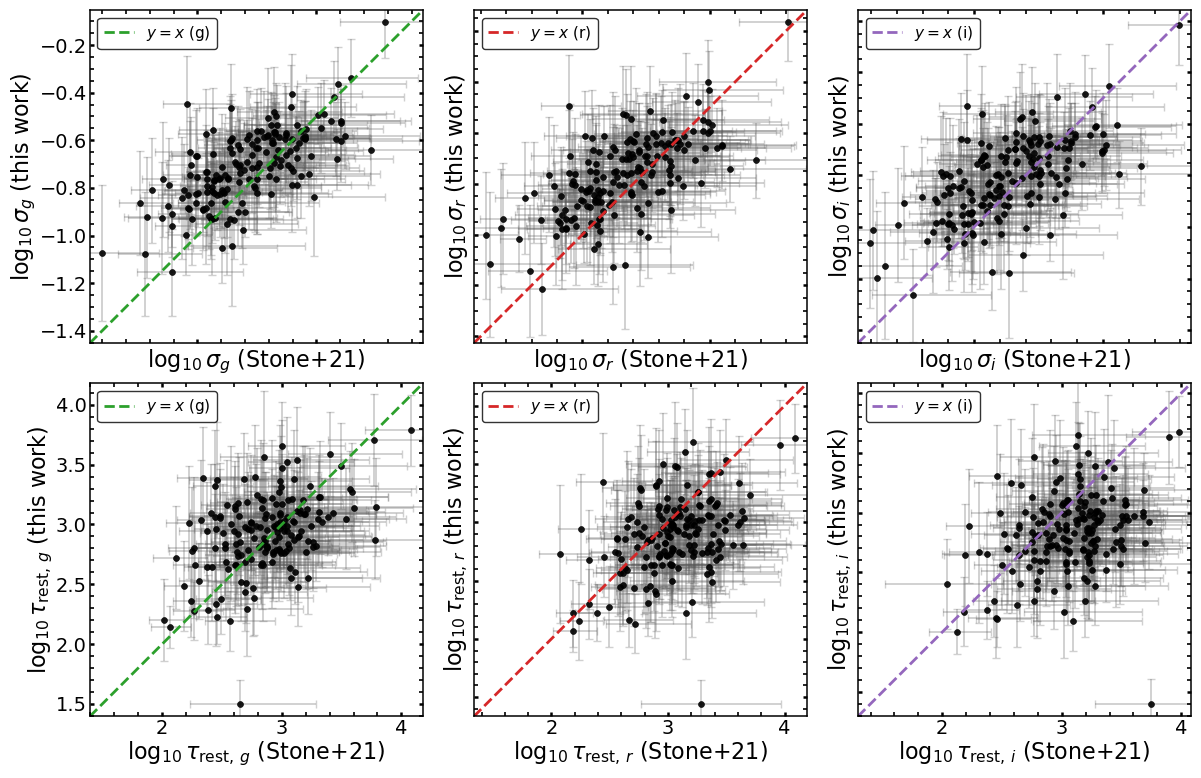

In [5]:
# Stone Comparison w/ poly1
sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}


# Load stone data
stone_df = pd.read_csv('data/aug8_stone_merged.csv')
stone_df['object_id'] = stone_df['object_id'].astype(str)

# Load standard data
agn_df = load_agn_data("results/data/aug19_stone_nobwb_poly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))
plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_wpoly1.pdf")


In [ ]:
# Same Length Comparison
sigma_keys = {
    'x': 'log_sigma_band_{band}_agn',
    'y': 'log_sigma_band_{band}_samelength',
    'xerr': 'log_sigma_band_{band}_err_agn',
    'yerr': 'log_sigma_band_{band}_err_samelength',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (same RF length)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_tau_band_{band}_RF_agn',
    'y': 'log_tau_band_{band}_RF_samelength',
    'xerr': 'log_tau_band_{band}_RF_err_agn',
    'yerr': 'log_tau_band_{band}_RF_err_samelength',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (same RF length)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

# Load AGN same length data
agn_samelength_df = load_agn_data("results/data/aug25_stone_nobwb_poly1_samelength2400_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_samelength_df['object_id'] = agn_samelength_df['object_id'].astype(str)

# Load standard data
agn_df = load_agn_data("results/data/aug19_stone_nobwb_poly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)

merged_agn_samelength = pd.merge(agn_samelength_df, agn_df, on='object_id', how='inner', suffixes=('_samelength', '_agn'))

plot_stone_vs_this_work(merged_agn_samelength, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_samelength_2400days.pdf")


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 313.49it/s]


Number of quasars loaded: 180
Number of quasars with 0 < z <= 1.0: 31
Number of quasars with z > 3: 8
Highest redshift quasar: 4.1577668182859
Columns with NaNs: ['apparent_mag_u', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err', 'mags_mean_u', 'mags_mean_g']
Skipping data cuts as apply_cut is False.


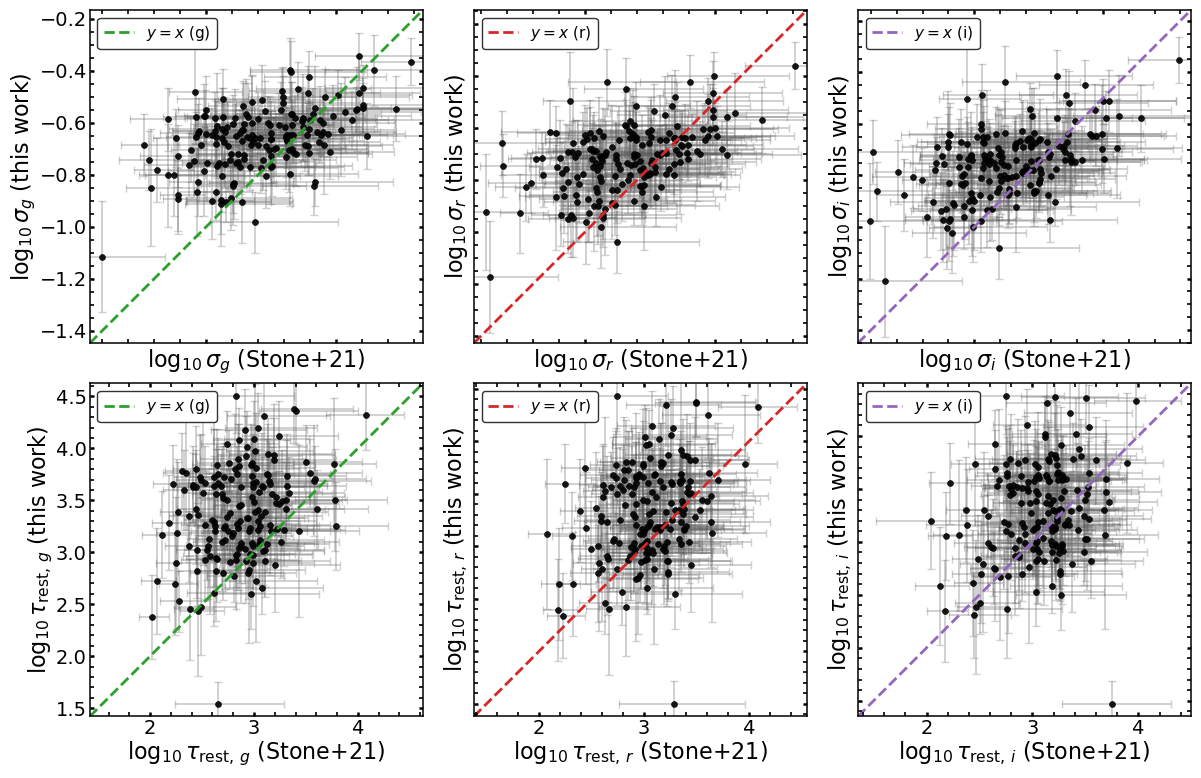

In [ ]:
# Stone Comparison wo/ poly1 w/ bwb

sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

# Load standard data
agn_df = load_agn_data("results/data/aug20_stone_bwb_nopoly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))


plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_bwb_wopoly1.pdf")


Reading quasars from HDF5: 100%|██████████| 180/180 [00:00<00:00, 310.74it/s]
/tmp/ipykernel_959447/4034639757.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agn_df[f'log_sigma_band_{band}_eq'] = np.log10(sigma_eq)
/tmp/ipykernel_959447/4034639757.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agn_df[f'log_tau_band_{band}_RF_eq'] = np.log10(tau_eq)
/tmp/ipykernel_959447/4034639757.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

Number of quasars loaded: 180
Number of quasars with 0 < z <= 1.0: 31
Number of quasars with z > 3: 8
Highest redshift quasar: 4.1577668182859
Columns with NaNs: ['apparent_mag_u', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err', 'mags_mean_u', 'mags_mean_g']
Skipping data cuts as apply_cut is False.


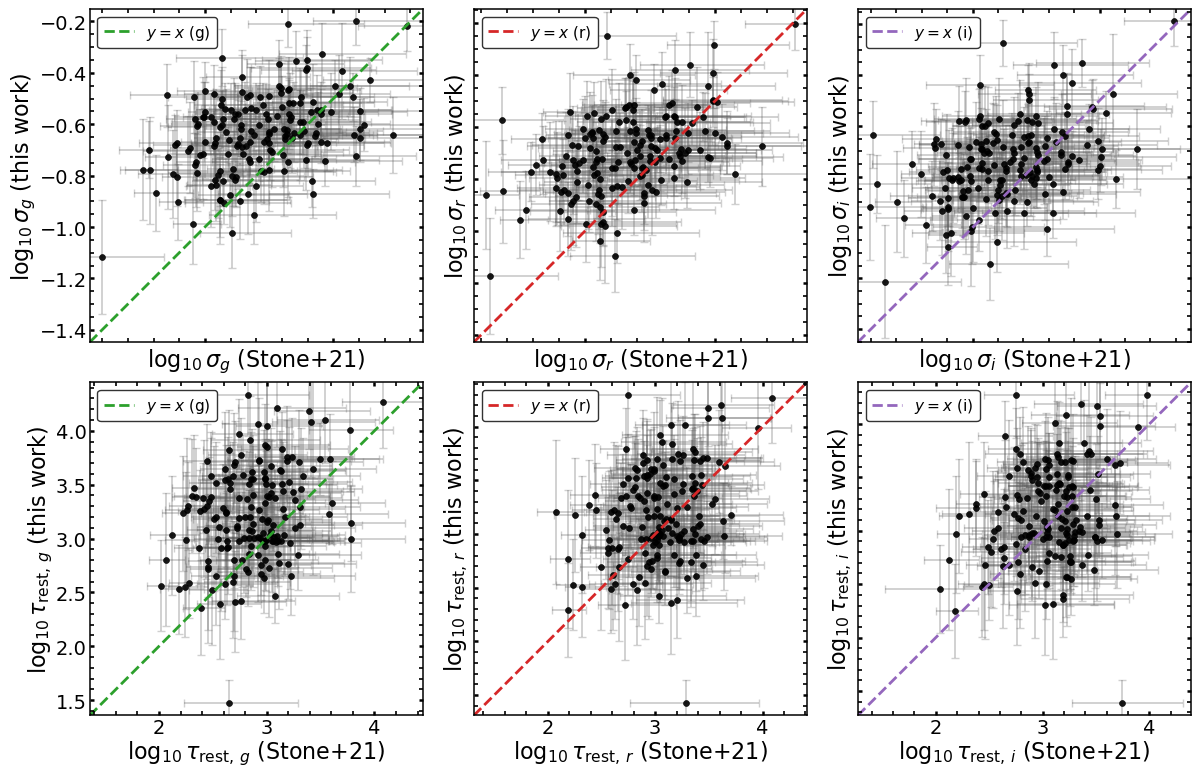

In [ ]:
# Stone Comparison bwb, no poly1

def drw_equiv(amp_cont, tau_drw, bwb_alpha, bwb_beta):
    A = amp_cont
    q2 = (bwb_alpha * A**2)**2  # q_b^2

    sigma2_eq = A**2 + 2.0 * q2
    tau_eq = tau_drw * (A**2 + (2.0/bwb_beta)*q2) / (A**2 + 2.0*q2)
    return np.sqrt(sigma2_eq), tau_eq

agn_df = load_agn_data("results/data/aug20_stone_bwb_poly1_carma21_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)
agn_df['object_id'] = agn_df['object_id'].astype(str)


for band in ('g','r','i'):
    sigma = 10**agn_df[f'log_sigma_band_{band}']
    tau = 10**agn_df[f'log_tau_band_{band}_RF']
    sigma_eq, tau_eq = drw_equiv(sigma, tau, bwb_alpha=agn_df['bwb_alpha'], bwb_beta=agn_df['bwb_beta'])
    agn_df[f'log_sigma_band_{band}_eq'] = np.log10(sigma_eq)
    agn_df[f'log_tau_band_{band}_RF_eq'] = np.log10(tau_eq)

merged_agn_stone = pd.merge(stone_df, agn_df, on='object_id', how='inner', suffixes=('_stone', '_agn'))

sigma_keys = {
    'x': 'log_SIGMA_{band}',
    'y': 'log_sigma_band_{band}_eq',
    'xerr': ('log_SIGMA_{band}_ERR_L', 'log_SIGMA_{band}_ERR_U'),
    'yerr': 'log_sigma_band_{band}_err',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (this work)',
}

tau_keys = {
    'x': 'log_TAU_REST_{band}',
    'y': 'log_tau_band_{band}_RF_eq',
    'xerr': ('log_TAU_REST_{band}_ERR_L', 'log_TAU_REST_{band}_ERR_U'),
    'yerr': 'log_tau_band_{band}_RF_err',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (Stone+21)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (this work)',
}

plot_stone_vs_this_work(merged_agn_stone, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/appendix/sigma_tau_stone_bwb_poly1.pdf")


Reading quasars from HDF5: 100%|██████████| 13160/13160 [00:48<00:00, 273.66it/s]


Number of quasars loaded: 13160
Number of quasars with 0 < z <= 1.0: 3204
Number of quasars with z > 3: 405
Highest redshift quasar: 4.455935435869128
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_i_obs', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_u', 'log_amp_delta_blr_u_err', 'log_jitter_g', 'log_jitter_g_err', 'log_jitter_u', 'log_jitter_u_err', 'log_lag_blr_g', 'log_lag_blr_g_err', 'log_lag_blr_u', 'log_lag_blr_u_err', 'log_sigma_band_g', 'log_sigma_band_g_err', 'log_sigma_band_u', 'log_sigma_band_u_err', 'log_tau_band_g_RF', 'log_tau_band_g_RF_err', 'log_tau_band_u_RF', 'log_tau_band_u_RF_err', 'mags_mean_g', 'mags_mean_u', 'mean_g', 'mean_g_err', 'mean_u', 'mean_u_err']
Skipping data cuts as apply_cut is False.


Reading quasars from HDF5: 100%|██████████| 3920/3920 [00:16<00:00, 243.79it/s]


Number of quasars loaded: 3920
Number of quasars with 0 < z <= 1.0: 965
Number of quasars with z > 3: 112
Highest redshift quasar: 4.32306007971774
Columns with NaNs: ['apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_i_obs', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err']
Skipping data cuts as apply_cut is False.


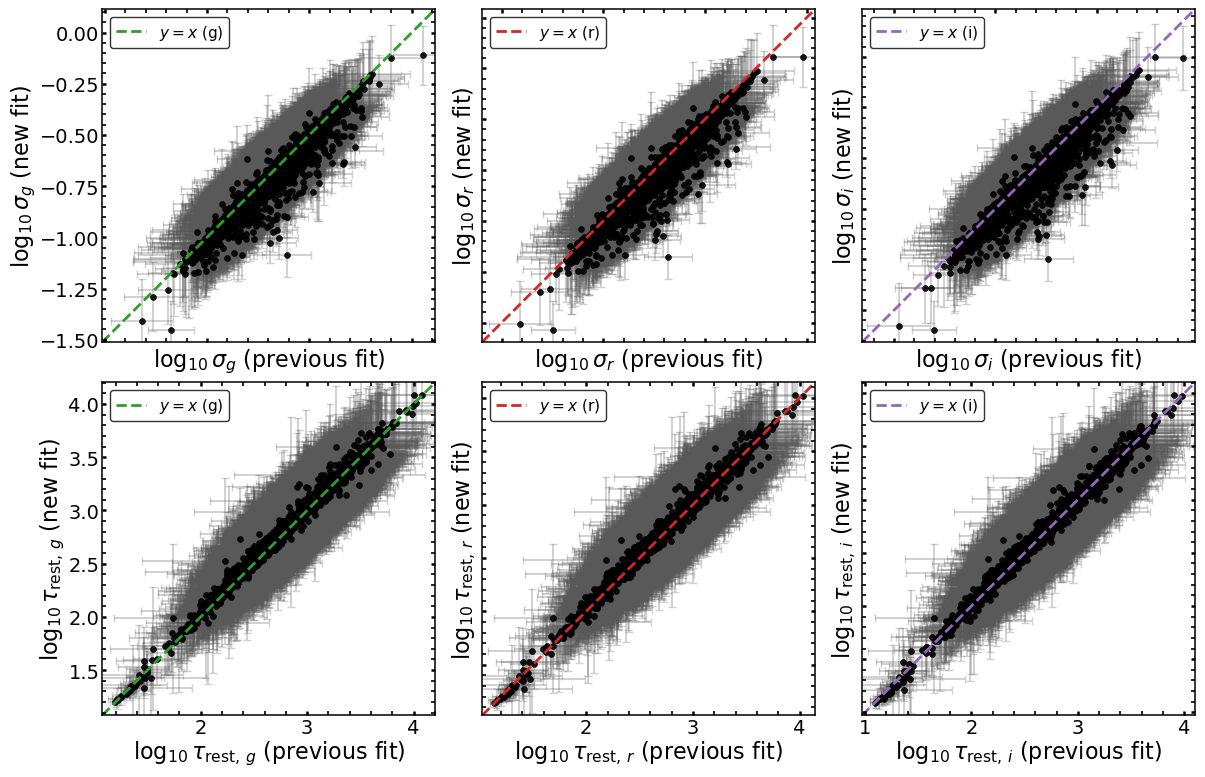

In [ ]:
# New fit compare
sigma_keys = {
    'x': 'log_sigma_band_{band}_old',
    'y': 'log_sigma_band_{band}_new',
    'xerr': 'log_sigma_band_{band}_err_old',
    'yerr': 'log_sigma_band_{band}_err_new',
    'xlabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (previous fit)',
    'ylabel': r'$\log_{{10}}\!\,\sigma_{{{band}}}$ (new fit)',
}

tau_keys = {
    'x': 'log_tau_band_{band}_RF_old',
    'y': 'log_tau_band_{band}_RF_new',
    'xerr': 'log_tau_band_{band}_RF_err_old',
    'yerr': 'log_tau_band_{band}_RF_err_new',
    'xlabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (previous fit)',
    'ylabel': r'$\log_{{10}}\!\,\tau_{{\mathrm{{rest}},\,{band}}}$ (new fit)',
}

agn_df_old = load_agn_data("results/data/aug29_chisq_nobwb_carma21_qscpu_N20w4000s1000t8c4_fittedm2500_diffalpha.h5", populate_sdss=False, apply_cut=False)
agn_df_old['object_id'] = agn_df_old['object_id'].astype(str)

agn_df_new = load_agn_data("results/data/aug31_chisq_alphalamcsv_nobwb_poly1_N20w4000s1000t8c4_fittedm2500.h5", populate_sdss=False, apply_cut=False)
agn_df_new['object_id'] = agn_df_new['object_id'].astype(str)

merged_df = pd.merge(agn_df_old, agn_df_new, on='object_id', how='inner', suffixes=('_old', '_new'))
plot_stone_vs_this_work(merged_df, sigma_keys, tau_keys, bands=('g','r','i'), figfile="plots/test/sigma_tau_oldnew.pdf")


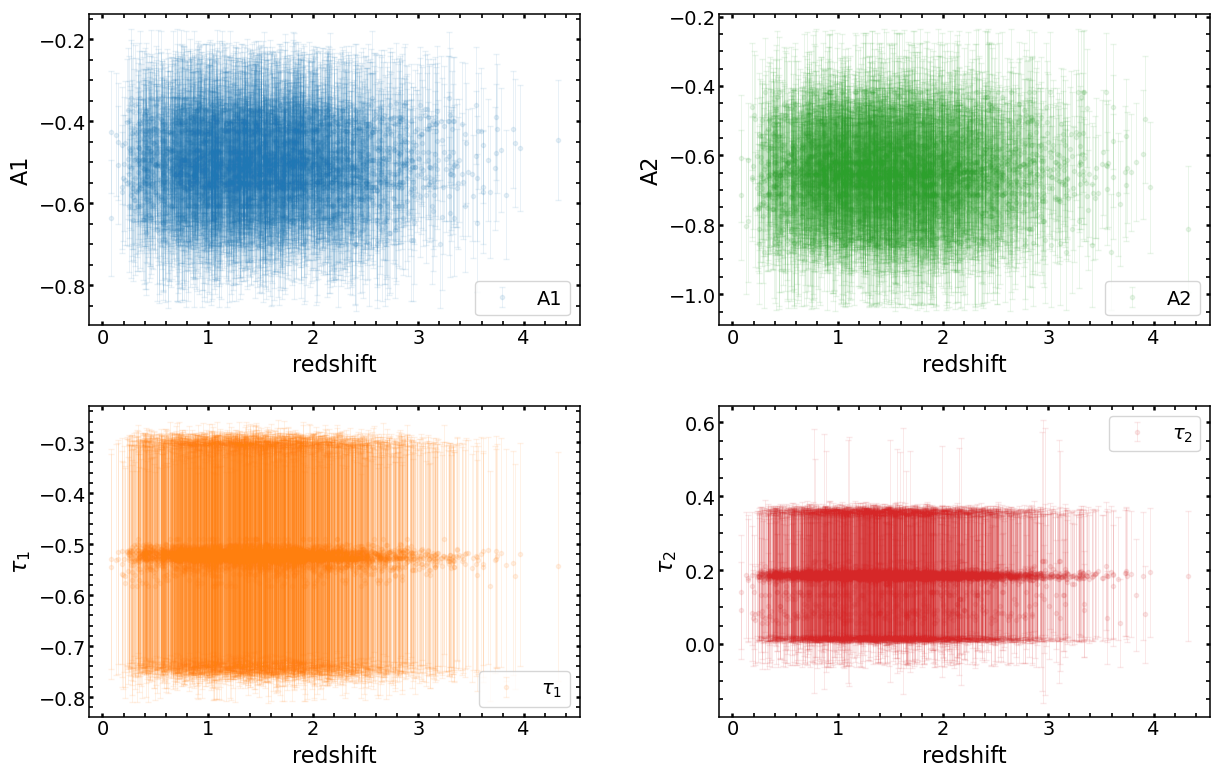

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.6), constrained_layout=True)
fig.set_constrained_layout_pads(w_pad=0.0, h_pad=0.01, wspace=0.1, hspace=0.08)

params = [
    ('eta_A1_mean', 'eta_A1_err', 'A1', 'tab:blue'),
    ('eta_A2_mean', 'eta_A2_err', 'A2', 'tab:green'),
    ('eta_tau1_mean', 'eta_tau1_err', r'$\tau_1$', 'tab:orange'),
    ('eta_tau2_mean', 'eta_tau2_err', r'$\tau_2$', 'tab:red'),
]

for ax, (mean_key, err_key, label, color) in zip(axes.flat, params):
    y = agn_df_new[mean_key]
    yerr = agn_df_new[err_key]
    x = agn_df_new['z']
    ax.errorbar(x, y, yerr=yerr, fmt='o', ms=3, color=color, alpha=0.1, label=label, elinewidth=0.7, capsize=2)
    ax.set_xlabel('redshift')
    ax.set_ylabel(label)
    ax.legend()
    ax.tick_params(direction='in', which='both', top=True, right=True, length=3, pad=2)
    for s in ax.spines.values():
        s.set_linewidth(1.1)

plt.show()